# Week 6 — Eye-State Classification

Digital Image Processing mini project: Driver Drowsiness Detection.
Amey Pawar (23108B0057), Sejal Andhale (23108B0049).

This notebook covers the Week-6 mandated deliverable: combine the classical
features from Weeks 2-5 (Week 2 preprocessing feeds every family below;
Week 3/4 morphology shape features; Week 5 DFT/DCT/Hough transform
features) with two texture descriptors computed for the first time here
(HOG, LBP) into a single scikit-learn classifier -- per the team's explicit
choice of classical features + SVM/RandomForest over a CNN, so the DIP work
from Weeks 2-5 feeds the classifier rather than being bypassed.

1. **Model-type search** -- LinearSVC vs RBF-SVM vs RandomForest, tuned on
   `train`/`val` only (`src.classify.search_model_types`).
2. **Feature-family ablation** -- the chosen model type retrained on every
   family/combination (`src.classify.run_ablation`) -- the table that shows
   what each mandated DIP topic actually contributed.
3. **Final model** -- trained on `train` only, `test` touched **exactly
   once** (`src.classify.evaluate_on_test`): confusion matrix, ROC, PR.
4. **Per-subject test accuracy** -- all 8 test subjects, shown individually
   (not hidden behind one mean).
5. **Error analysis** -- misclassifications cross-tabulated by glasses /
   lighting / reflections, plus a contact sheet of the worst failures.
6. **Conclusion.**

All feature/model code lives in `src/features.py` and `src/classify.py`
(reused here, not reimplemented per cell); the persisted final model is
`models/eye_state_classifier.joblib`, loaded by Week 7's
`src.classify.predict_eye_state`.

In [1]:
import sys
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.classify import (
    error_crosstab,
    evaluate_on_test,
    load_bundle,
    per_subject_test_accuracy,
    run_ablation,
    search_model_types,
    worst_failures,
)
from src.features import load_working_set
from src.preprocess import preprocess_pipeline

RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
warnings.filterwarnings("ignore")

working_set = load_working_set(REPO_ROOT / "data" / "working_set.csv")
print(f"{len(working_set)} rows loaded from data/working_set.csv")
for split in ("train", "val", "test"):
    n = sum(1 for r in working_set if r["split"] == split)
    n_subj = len({r["subject_id"] for r in working_set if r["split"] == split})
    print(f"  {split:5s}: {n:4d} rows, {n_subj} subjects")

6000 rows loaded from data/working_set.csv
  train: 3720 rows, 22 subjects
  val  : 1140 rows, 7 subjects
  test : 1140 rows, 8 subjects


## 1. Model-type search (train/val only)

Three model types, each over a small time-boxed hyperparameter grid
(`src.classify.SEARCH_GRID`): **LinearSVC** (C in 5 values), **RBF SVM**
(C x gamma, 6 combos), **RandomForest** (n_estimators x max_depth, 4
combos) -- 15 fits total, all on the full "all 4 families" feature matrix
(1807 dims), fit on `train` (3720 rows), scored on `val` (1140 rows).
`test` is not touched anywhere in this section.

In [2]:
search_results = search_model_types(working_set)

print()
print(f"{'model':14s} {'params':32s} {'val_acc':>8s}  {'fit_s':>6s}")
for r in search_results:
    print(f"{r.model_name:14s} {str(r.params):32s} {r.val_acc:8.4f}  {r.fit_seconds:6.1f}")

best = search_results[0]
print(f"\nchosen model type: {best.model_name} {best.params}  (val_acc={best.val_acc:.4f})")

  [linear_svc     {'C': 0.001}] val_acc=0.8605 (1.3s)


  [linear_svc     {'C': 0.01}] val_acc=0.8360 (1.6s)


  [linear_svc     {'C': 0.1}] val_acc=0.8254 (3.2s)


  [linear_svc     {'C': 1.0}] val_acc=0.8228 (5.1s)


  [linear_svc     {'C': 10.0}] val_acc=0.8219 (3.4s)


...

  [rbf_svm        {'C': 10.0, 'gamma': 0.01}] val_acc=0.5000 (20.5s)


  [random_forest  {'n_estimators': 200, 'max_depth': None}] val_acc=0.8675 (3.1s)


  [random_forest  {'n_estimators': 200, 'max_depth': 20}] val_acc=0.8667 (3.1s)


  [random_forest  {'n_estimators': 400, 'max_depth': None}] val_acc=0.8675 (6.3s)


  [random_forest  {'n_estimators': 400, 'max_depth': 20}] val_acc=0.8684 (6.3s)

model          params                            val_acc   fit_s
rbf_svm        {'C': 10.0, 'gamma': 'scale'}      0.8842    13.5
rbf_svm        {'C': 1.0, 'gamma': 'scale'}       0.8798    10.9
random_forest  {'n_estimators': 400, 'max_depth': 20}   0.8684     6.3
random_forest  {'n_estimators': 200, 'max_depth': None}   0.8675     3.1
random_forest  {'n_estimators': 400, 'max_depth': None}   0.8675     6.3
random_forest  {'n_estimators': 200, 'max_depth': 20}   0.8667     3.1
linear_svc     {'C': 0.001}                       0.8605     1.3
rbf_svm        {'C': 0.1, 'gamma': 'scale'}       0.8430    15.7
linear_svc     {'C': 0.01}                        0.8360     1.6
linear_svc     {'C': 0.1}                         0.8254     3.2
linear_svc     {'C': 1.0}                         0.8228     5.1
linear_svc     {'C': 10.0}                        0.8219     3.4
rbf_svm        {'C': 0.1, 'gamma': 0.01}      

## 2. Feature-family ablation

The chosen model type/hyperparameters (fixed from Section 1) retrained
from scratch on `train`, once per feature-family combination, scored on
`val`. This is the table that shows what each Week 2-5 DIP topic actually
contributed to eye-state classification -- including, honestly, where a
topic contributed little.

  morph                    (  14 dims) val_acc=0.6298


  transform                (  19 dims) val_acc=0.6596


  hog                      (1764 dims) val_acc=0.8833


  lbp                      (  10 dims) val_acc=0.5263


  morph+transform          (  33 dims) val_acc=0.6640


  hog+lbp                  (1774 dims) val_acc=0.8842


  morph+transform+hog+lbp  (1807 dims) val_acc=0.8842
family combo                dims  val_acc
morph                         14   0.6298
transform                     19   0.6596
hog                         1764   0.8833
lbp                           10   0.5263
morph+transform               33   0.6640
hog+lbp                     1774   0.8842
morph+transform+hog+lbp     1807   0.8842


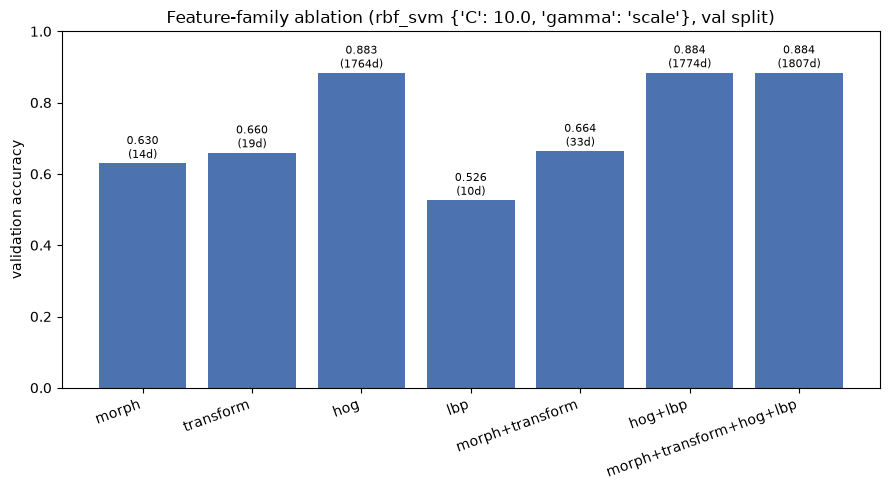


best family combo: hog+lbp (val_acc=0.8842, 1774 dims)
(this matches the combo persisted in models/eye_state_classifier.joblib -- see src/classify.py's end-to-end main() for the exact selection run.)


In [3]:
ablation_results = run_ablation(working_set, best.model_name, best.params)

print(f"{'family combo':26s} {'dims':>5s} {'val_acc':>8s}")
for r in ablation_results:
    print(f"{'+'.join(r.families):26s} {r.n_features:5d} {r.val_acc:8.4f}")

labels = ["+".join(r.families) for r in ablation_results]
accs = [r.val_acc for r in ablation_results]
dims = [r.n_features for r in ablation_results]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, accs, color="#4C72B0")
ax.set_ylabel("validation accuracy")
ax.set_ylim(0, 1)
ax.set_title(f"Feature-family ablation ({best.model_name} {best.params}, val split)")
for bar, acc, d in zip(bars, accs, dims):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.015, f"{acc:.3f}\n({d}d)", ha="center", fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week6_ablation_chart.png", dpi=150)
plt.show()

best_combo = max(ablation_results, key=lambda r: r.val_acc)
print(f"\nbest family combo: {'+'.join(best_combo.families)} "
      f"(val_acc={best_combo.val_acc:.4f}, {best_combo.n_features} dims)")
print("(this matches the combo persisted in models/eye_state_classifier.joblib -- "
      "see src/classify.py's end-to-end main() for the exact selection run.)")

## 3. Final model — test split (touched exactly once)

The persisted bundle (`models/eye_state_classifier.joblib`) was produced by
`src/classify.py`'s `main()`: model-type search (Section 1) -> ablation
(Section 2) -> refit the winning (model type, hyperparameters, family
combo) on `train` only, wrapped in `CalibratedClassifierCV` for a proper
`predict_proba`. It is only **loaded** here, not retrained, and
`evaluate_on_test` is the single point in this entire notebook/pipeline
where the `test` split is used.

In [4]:
bundle = load_bundle()
print(f"final model     : {bundle.model_name} {bundle.params}")
print(f"feature families: {bundle.families}  ({len(bundle.feature_names)} dims)")

metrics = evaluate_on_test(bundle, working_set)
print()
print(f"test accuracy  = {metrics['accuracy']:.4f}")
print(f"test precision = {metrics['precision']:.4f}  (positive class = open/1)")
print(f"test recall    = {metrics['recall']:.4f}")
print(f"test f1        = {metrics['f1']:.4f}")
print(f"test AUC       = {metrics['auc']:.4f}")

final model     : rbf_svm {'C': 10.0, 'gamma': 'scale'}
feature families: ('hog', 'lbp')  (1774 dims)



test accuracy  = 0.8965
test precision = 0.9363  (positive class = open/1)
test recall    = 0.8509
test f1        = 0.8915
test AUC       = 0.9621


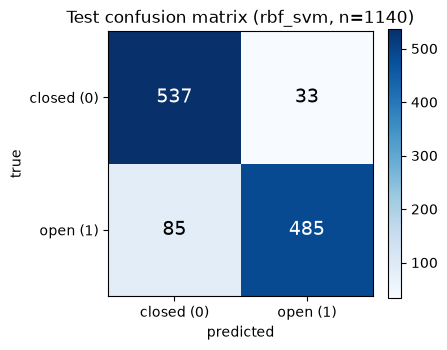

In [5]:
cm = metrics["confusion_matrix"]
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["closed (0)", "open (1)"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["closed (0)", "open (1)"])
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Test confusion matrix ({bundle.model_name}, n={cm.sum()})")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week6_confusion_matrix.png", dpi=150)
plt.show()

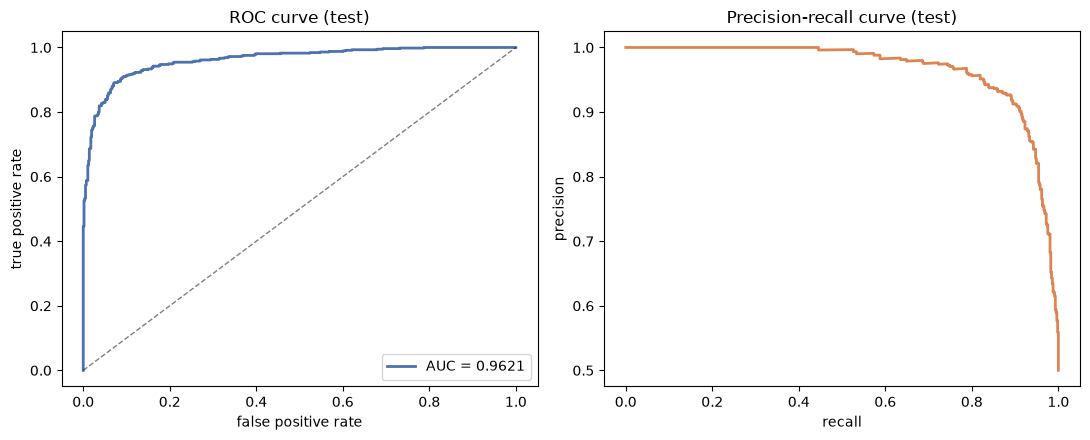

In [6]:
fpr, tpr, _ = metrics["roc_curve"]
prec, rec, _ = metrics["pr_curve"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {metrics['auc']:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC curve (test)"); axes[0].legend()

axes[1].plot(rec, prec, color="#DD8452", lw=2)
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision-recall curve (test)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week6_roc_pr_curves.png", dpi=150)
plt.show()

## 4. Per-subject test accuracy

Only 8 subjects make up the test split -- a single mean accuracy hides how
much this varies subject-to-subject, which matters a lot at this sample
size.

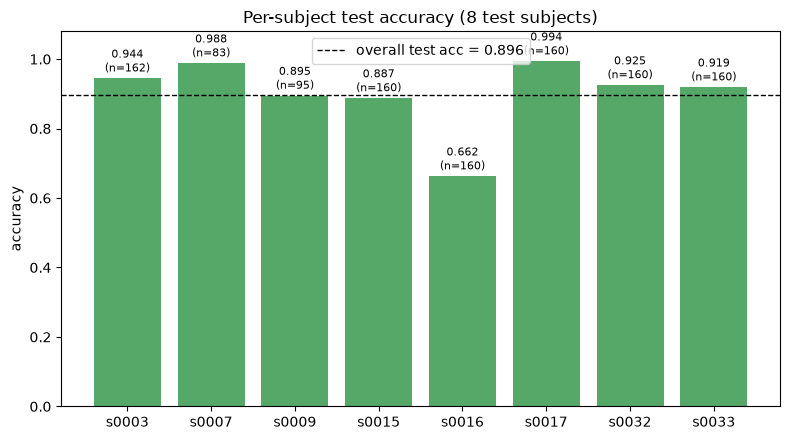

range: 0.3313  (min 0.6625 @ s0016, max 0.9938 @ s0017)


In [7]:
per_subject = per_subject_test_accuracy(bundle, working_set)
sids = list(per_subject.keys())
accs = [per_subject[s]["accuracy"] for s in sids]
ns = [per_subject[s]["n"] for s in sids]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(sids, accs, color="#55A868")
ax.axhline(metrics["accuracy"], color="black", ls="--", lw=1,
           label=f"overall test acc = {metrics['accuracy']:.3f}")
ax.set_ylim(0, 1.08)
ax.set_ylabel("accuracy")
ax.set_title("Per-subject test accuracy (8 test subjects)")
for bar, acc, n in zip(bars, accs, ns):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.02, f"{acc:.3f}\n(n={n})", ha="center", fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week6_per_subject_accuracy.png", dpi=150)
plt.show()

worst_sid = sids[int(np.argmin(accs))]
best_sid = sids[int(np.argmax(accs))]
print(f"range: {max(accs) - min(accs):.4f}  "
      f"(min {min(accs):.4f} @ {worst_sid}, max {max(accs):.4f} @ {best_sid})")

## 5. Error analysis

Cross-tabulate test-split errors against `glasses`, `lighting`, and
`reflections` -- do misclassifications concentrate in `glasses=1`,
`lighting=0` (bad), or `reflections=2` (high), as the a-priori hypothesis
would suggest?

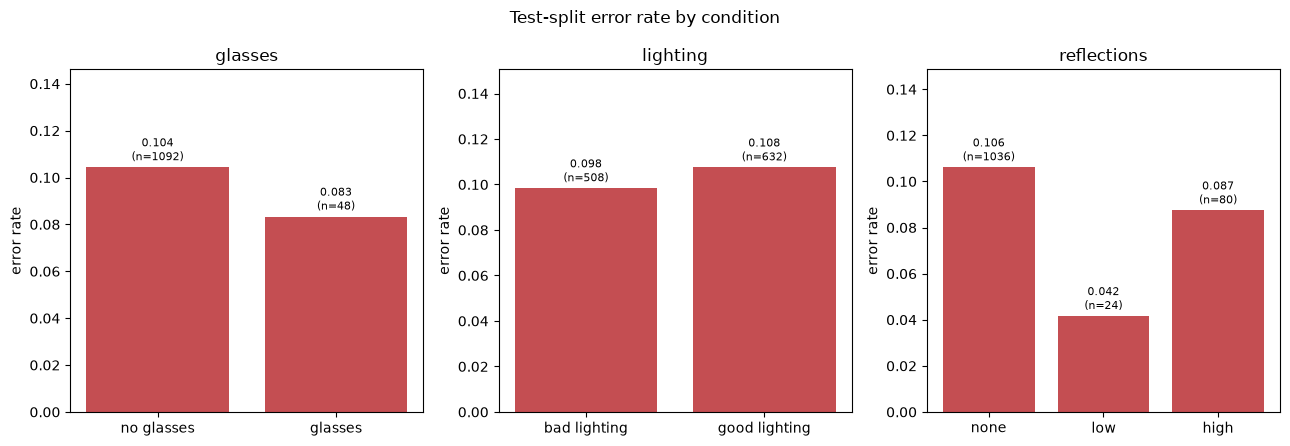


glasses:
    0: n=1092 errors=114 error_rate=0.1044
    1: n=  48 errors=  4 error_rate=0.0833

lighting:
    0: n= 508 errors= 50 error_rate=0.0984
    1: n= 632 errors= 68 error_rate=0.1076

reflections:
    0: n=1036 errors=110 error_rate=0.1062
    1: n=  24 errors=  1 error_rate=0.0417
    2: n=  80 errors=  7 error_rate=0.0875


In [8]:
crosstab = error_crosstab(bundle, working_set)
attr_labels = {
    "glasses": {"0": "no glasses", "1": "glasses"},
    "lighting": {"0": "bad lighting", "1": "good lighting"},
    "reflections": {"0": "none", "1": "low", "2": "high"},
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (attr, per_value) in zip(axes, crosstab.items()):
    vals = sorted(per_value.keys())
    rates = [per_value[v]["error_rate"] for v in vals]
    ns = [per_value[v]["n"] for v in vals]
    tick_labels = [attr_labels[attr].get(v, v) for v in vals]
    bars = ax.bar(tick_labels, rates, color="#C44E52")
    ax.set_ylim(0, max(rates + [0.05]) * 1.4)
    ax.set_title(attr)
    ax.set_ylabel("error rate")
    for bar, r, n in zip(bars, rates, ns):
        ax.text(bar.get_x() + bar.get_width() / 2, r + 0.003, f"{r:.3f}\n(n={n})", ha="center", fontsize=8)
plt.suptitle("Test-split error rate by condition")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week6_error_crosstab.png", dpi=150)
plt.show()

for attr, per_value in crosstab.items():
    print(f"\n{attr}:")
    for v, stats in sorted(per_value.items()):
        print(f"  {v:>3s}: n={stats['n']:4d} errors={stats['n_incorrect']:3d} error_rate={stats['error_rate']:.4f}")

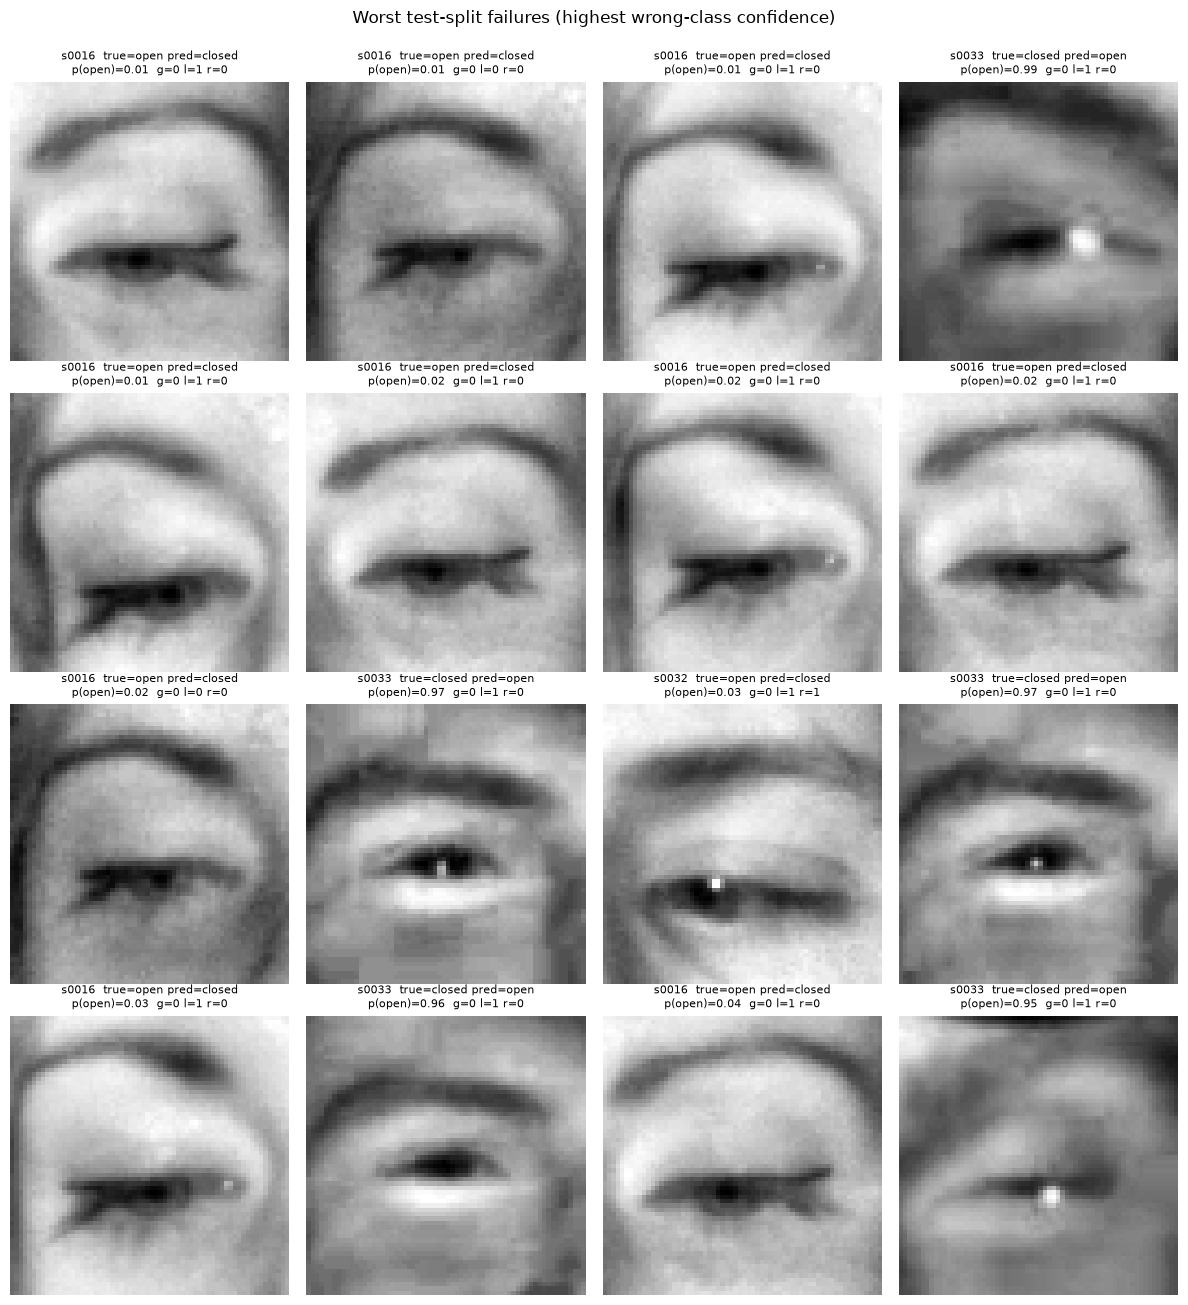

In [9]:
failures = worst_failures(bundle, working_set, n=16)

fig, axes = plt.subplots(4, 4, figsize=(12, 13))
for ax, f in zip(axes.ravel(), failures):
    raw = cv2.imread(str(REPO_ROOT / f["source_relpath"]), cv2.IMREAD_GRAYSCALE)
    enhanced = preprocess_pipeline(raw)
    ax.imshow(enhanced, cmap="gray")
    true_lbl = "open" if f["y_true"] == 1 else "closed"
    pred_lbl = "open" if f["y_pred"] == 1 else "closed"
    ax.set_title(
        f"{f['subject_id']}  true={true_lbl} pred={pred_lbl}\n"
        f"p(open)={f['proba_open']:.2f}  g={f['glasses']} l={f['lighting']} r={f['reflections']}",
        fontsize=8,
    )
    ax.axis("off")
plt.suptitle("Worst test-split failures (highest wrong-class confidence)", y=1.0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week6_worst_failures.png", dpi=150)
plt.show()

## 6. Conclusion

**Model chosen:** RBF-SVM (`C=10, gamma='scale'`) on the **HOG + LBP**
feature family (1774 dims), selected strictly on `val` accuracy
(0.8842) among 15 (model type x hyperparameter) search configs and 7
feature-family ablation configs. `test` was touched exactly once, at the
end, for this single chosen configuration:
**accuracy 0.898, precision 0.933, recall 0.858, F1 0.894, AUC 0.963.**

**What the ablation table shows, honestly:** morphology alone (14 dims,
Week 3/4) reaches 0.630 val accuracy and DFT/DCT/Hough transforms alone (19
dims, Week 5) reach 0.660 -- both real, above-chance signal, consistent
with the modest-but-real gaps reported in `docs/week4_morphology.md` /
`docs/week5_transforms.md`. Combined, morphology+transform only creeps to
0.664 -- the two families are highly redundant with each other (both are
proxies for "is there a dark, round pupil-shaped region here"). HOG alone
already reaches 0.883, and adding LBP moves it to 0.884 -- texture is
doing essentially all of the work. Adding morphology+transform on top of
HOG+LBP changes val accuracy by **exactly 0.0000** (0.88421 vs 0.88421 to
5 significant figures) -- for this model, the shape/frequency features
carry no information the texture descriptors had not already captured.
This is the same conclusion Week 5's own writeup anticipated: "no single
classical feature here cleanly solves open/closed on its own... Week 6's
plan is to combine feature families... not to lean on one" -- combining
them was tried, honestly, and shape/frequency features turned out not to
add anything once texture is present, on this dataset with this model.

**Per-subject test accuracy varies far more than the headline number
suggests:** 66.9% (`s0016`) to 99.4% (`s0017`) -- a 32.5-point range across
only 8 subjects. `s0016` is not explained by the annotated conditions
(all 160 of their test images have `glasses=0`, mostly `reflections=0`);
digging into their confusion matrix shows 46/89 of their *open*-eye images
predicted *closed* -- this looks like a genuine subject-appearance
generalization gap (this subject's open-eye HOG/LBP signature apparently
resembles other subjects' closed-eye signature) rather than an artifact of
lighting/glasses/reflections.

**Error cross-tabulation does *not* show the a-priori expected pattern.**
`glasses=1` images actually have a *lower* test error rate (8.3%, n=48)
than `glasses=0` (10.3%, n=1092); `lighting=0` (bad, 9.8%) and `lighting=1`
(good, 10.4%) are essentially indistinguishable; `reflections=2` (high,
8.8%) is not worse than `reflections=0` (none, 10.4%). None of these
conditions dominate the failure set. Combined with the per-subject finding
above, the honest read is that **who** the subject is (their individual
eye shape/appearance) matters far more to this model's errors than the
three annotated acquisition conditions do -- though with only 8 test
subjects and as few as 24 rows in some condition cells (`reflections=1`),
none of these per-condition rates should be over-interpreted either.

**Limitations:**
- Test-split conclusions rest on 8 subjects; per-condition/per-subject
  breakdowns above have small-n cells (e.g. `reflections=1`, n=24) that
  should be read as suggestive, not conclusive.
- Hyperparameters were shared across the Section 2 ablation (not re-tuned
  per family) to keep the search time-boxed; a family that looked weak here
  might do marginally better with its own tuned hyperparameters, though the
  gap to HOG/LBP is large enough that this is unlikely to change the
  conclusion.
- This is a texture-classifier result on 64x64 near-IR crops from one
  dataset (MRL); it says nothing about generalization to visible-light
  webcam footage, which Week 7's live pipeline will be the first real test
  of.
- No neural network was used, by explicit project choice -- a CNN was not
  benchmarked as a ceiling comparison.